In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv(r"C:\Users\admin\Desktop\Sem lab\TSA\FINAL_USO.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date")
data.set_index("Date", inplace=True)

print(f"Data from {data.index.min().date()} to {data.index.max().date()}")
print(f"Total records: {len(data)}")

Data from 2011-12-15 to 2018-12-31
Total records: 1718


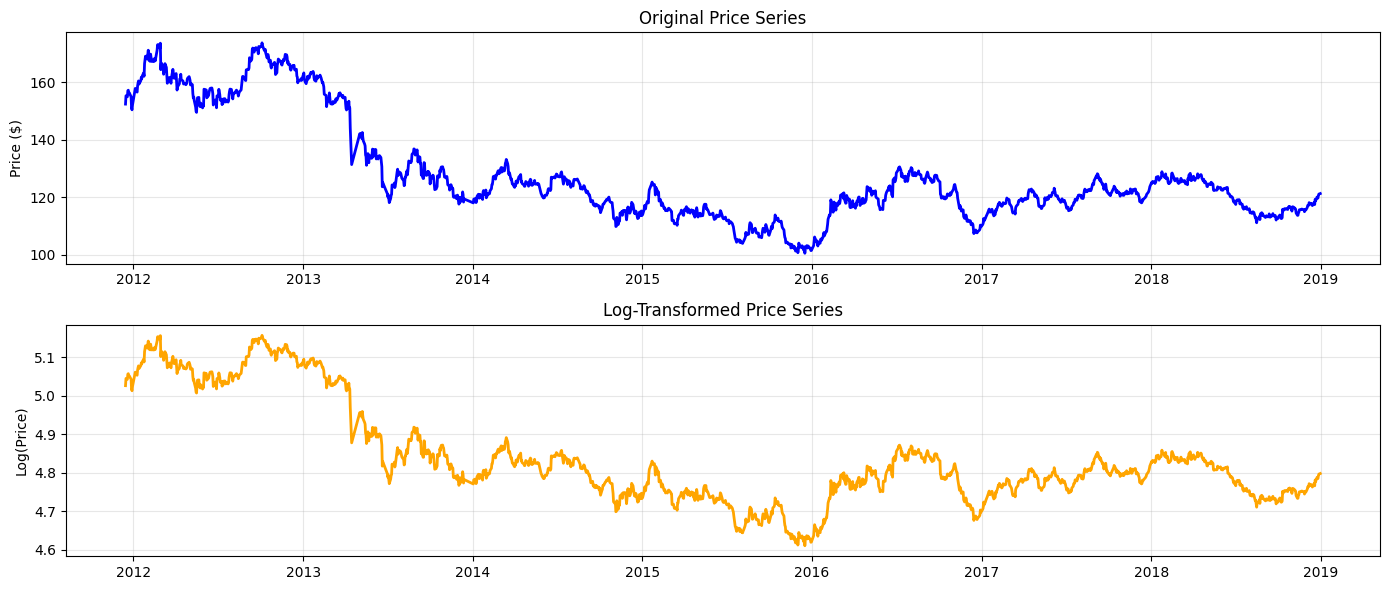


LOG TRANSFORMATION:
Original Mean: $127.32
Log Mean: 4.8380
Original Std Dev: $17.54
Log Std Dev: 0.1293


In [12]:
# LOG TRANSFORMATION
# Log transformation stabilizes variance
log_price = np.log(data["Close"])

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Original series
axes[0].plot(data.index, data["Close"], color="blue", linewidth=2)
axes[0].set_title("Original Price Series")
axes[0].set_ylabel("Price ($)")
axes[0].grid(True, alpha=0.3)

# Log transformed series
axes[1].plot(data.index, log_price, color="orange", linewidth=2)
axes[1].set_title("Log-Transformed Price Series")
axes[1].set_ylabel("Log(Price)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLOG TRANSFORMATION:")
print(f"Original Mean: ${data['Close'].mean():.2f}")
print(f"Log Mean: {log_price.mean():.4f}")
print(f"Original Std Dev: ${data['Close'].std():.2f}")
print(f"Log Std Dev: {log_price.std():.4f}")

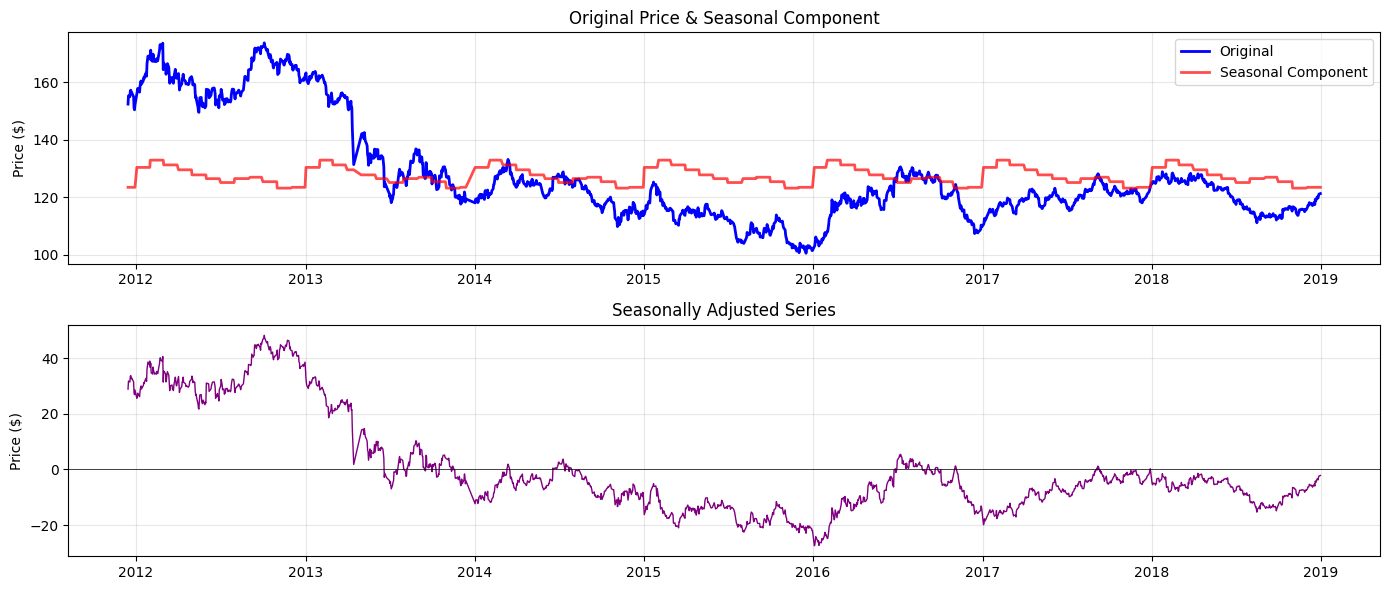


SEASONAL ADJUSTMENT:
Original Mean: $127.32
Deseasonalized Mean: $0.00
Deseasonalized Std Dev: $17.29


In [13]:
# SEASONAL ADJUSTMENT
# Calculate seasonal component (by month average)
data["Month"] = data.index.month
seasonal_component = data.groupby("Month")["Close"].transform("mean")
deseasonalized = data["Close"] - seasonal_component

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Original series
axes[0].plot(data.index, data["Close"], color="blue", linewidth=2, label="Original")
axes[0].plot(
    data.index,
    seasonal_component,
    color="red",
    linewidth=2,
    label="Seasonal Component",
    alpha=0.7,
)
axes[0].set_title("Original Price & Seasonal Component")
axes[0].set_ylabel("Price ($)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Deseasonalized series
axes[1].plot(data.index, deseasonalized, color="purple", linewidth=1)
axes[1].set_title("Seasonally Adjusted Series")
axes[1].set_ylabel("Price ($)")
axes[1].axhline(y=0, color="black", linestyle="-", linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSEASONAL ADJUSTMENT:")
print(f"Original Mean: ${data['Close'].mean():.2f}")
print(f"Deseasonalized Mean: ${deseasonalized.mean():.2f}")
print(f"Deseasonalized Std Dev: ${deseasonalized.std():.2f}")

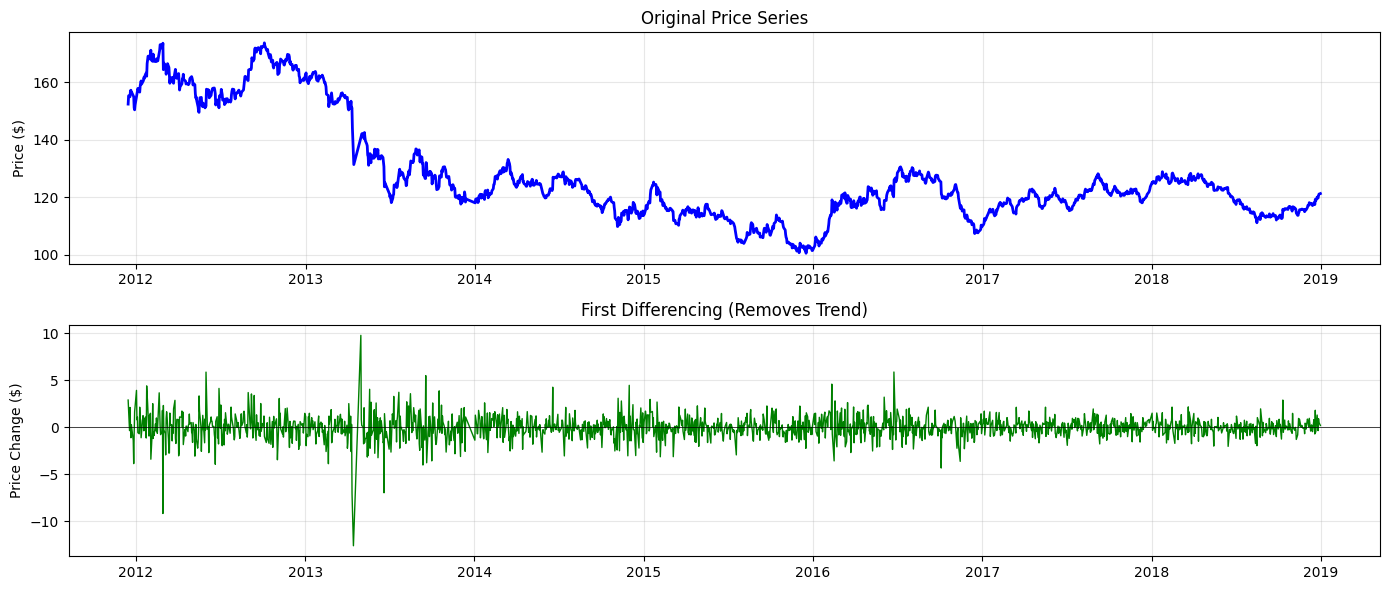


REGULAR DIFFERENCING:
Original Mean: $127.32
Differenced Mean: $-0.02
Differenced Std Dev: $1.26


In [14]:
# REGULAR DIFFERENCING
# First difference to remove trend
differenced = data["Close"].diff()

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Original series
axes[0].plot(data.index, data["Close"], color="blue", linewidth=2)
axes[0].set_title("Original Price Series")
axes[0].set_ylabel("Price ($)")
axes[0].grid(True, alpha=0.3)

# Differenced series
axes[1].plot(data.index, differenced, color="green", linewidth=1)
axes[1].set_title("First Differencing (Removes Trend)")
axes[1].set_ylabel("Price Change ($)")
axes[1].axhline(y=0, color="black", linestyle="-", linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nREGULAR DIFFERENCING:")
print(f"Original Mean: ${data['Close'].mean():.2f}")
print(f"Differenced Mean: ${differenced.mean():.2f}")
print(f"Differenced Std Dev: ${differenced.std():.2f}")

## Time Series Transformations